# Solution Space IV: Evaluating the Selected MLP

<br>

## Learning Objectives and Lesson Structure

Earlier notebooks separated the ingredients of a learning system:

$$
\mathcal{D}+\mathcal{H}_{\mathrm{MLP}}+\mathcal{O}\rightarrow s.
$$

Here $\mathcal{D}$ is the observed dataset, $\mathcal{H}_{\mathrm{MLP}}$ is the MLP hypothesis class, $\mathcal{O}$ is the training and selection procedure, and $s$ is the selected trained model.

This notebook asks what we can responsibly say about that selected model:

$$
\text{What behaviour of }s\text{ does this evidence support?}
$$

A single score is useful, but incomplete. Aggregate RMSE can hide local failure, sparse-support behaviour, context-shift failure, or instability across training runs. The practical object in this notebook is an evaluation protocol:

$$
\Pi=(\text{splits},\text{metrics},\text{plots},\text{slices},\text{diagnostic sets},\text{reporting rules}).
$$

The purpose of $\Pi$ is to turn predictions from $s$ into evidence about a claim.

By the end, students should be able to:

- distinguish training, validation, final test, and diagnostic evidence;
- explain why aggregate error is not enough;
- inspect residuals, prediction curves, and slice metrics;
- evaluate interpolation, sparse support, range stress, and context shift;
- connect failure modes back to $\mathcal{D}$, $\mathcal{H}_{\mathrm{MLP}}$, $\mathcal{O}$, and the evidence protocol;
- write a claim-specific supported / unsupported / unresolved assessment.

The notebook is organised around nine questions:

1. **What selected model are we evaluating?**
2. **What claim does the evidence need to support?**
3. **What role does each split play?**
4. **What does average performance show?**
5. **What function did the MLP learn?**
6. **Where does performance change?**
7. **What happens in interpolation, sparse support, and holdout regimes?**
8. **Does behaviour survive context shift?**
9. **What claim does the evidence support?**

The recurring researcher-facing question is:

$$
\text{Which behaviour is tested, by which evidence, and with what limitation?}
$$

<br>

## Setup

Run this cell first. It imports the plotting, data, model, and reporting helpers used throughout the notebook. The modelling choices appear in the section cells rather than here.

In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops.data_space import f0, local_count
from nextgen2026_mlai_workshops.solution_space import *

configure_solution_matplotlib()

<br>

## 1. What Selected Model Are We Evaluating?

### Motivation

Evaluation begins by naming the object being evaluated. The candidate is not just "an MLP." It is a trained MLP selected by a particular dataset, split, architecture, optimiser, and validation rule.

This section asks:

$$
\text{What exactly is the selected model }s\text{?}
$$

### Minimal example

The cell below creates the observed dataset, train/validation/final-test split, diagnostic sets, simple baselines, and a reference MLP. It also reports a compact dashboard before later sections break the behaviour apart.

| Ingredient | Value 1 | Value 2 | Value 3 |
|---|---|---|---|
| Dataset $\mathcal{D}$ | 420 | sparse_feature | increasing |
| Hypothesis $\mathcal{H}_{\mathrm{MLP}}$ | width 64 | depth 2 | relu |
| Training $\mathcal{O}$ | adam | 0.01 | 240 epochs |
| Protocol $\Pi$ | stratified_by_x_bin | train/validation/final test | diagnostics held aside |

| Selected model | Best epoch | Inputs | Selection rule |
|---|---|---|---|
| Reference MLP | 240 | ('x',) | minimum validation RMSE |

| Dashboard quantity | Value | Evidence |
|---|---|---|
| train RMSE | 0.1808 | train |
| validation RMSE | 0.1661 | validation |
| final test RMSE | 0.1536 | final test |
| (60, 70) RMSE | 0.1757 | final test slice |
| low-density RMSE | 0.1062 | lowest 30% support, cutoff 28.0 |
| shifted-context RMSE | 0.2315 | diagnostic set |
| worst-slice RMSE | 0.2127 | final test slices with n >= 10 |
| seed standard deviation |  | computed in the stability section |

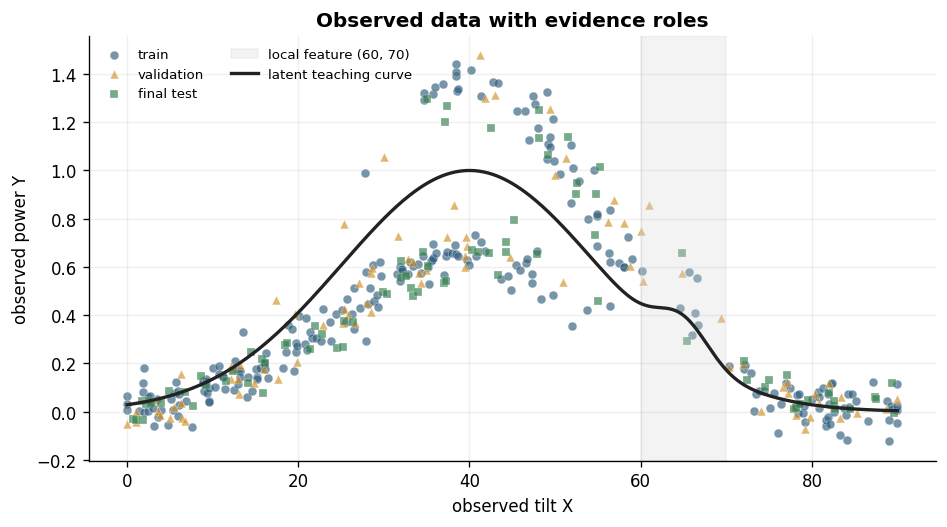

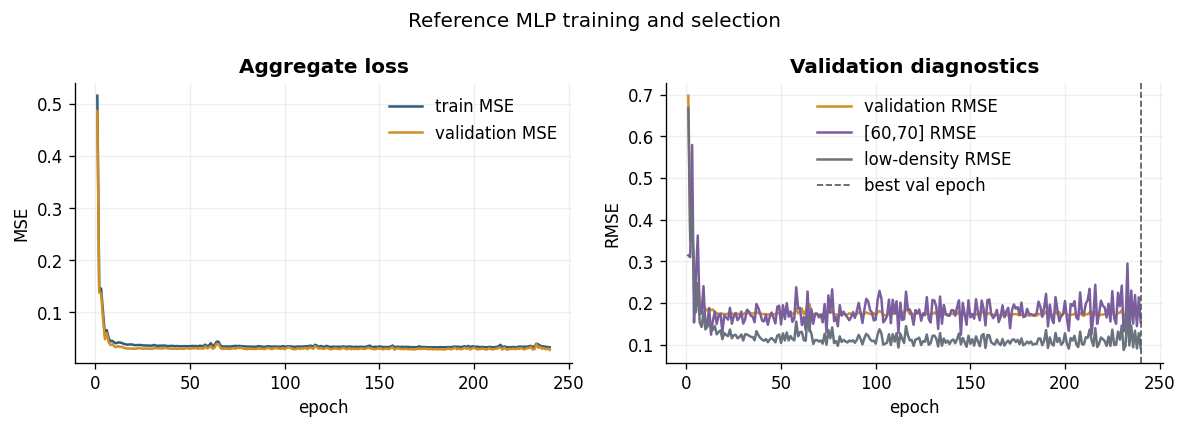

In [2]:
# Change these values, then rerun this cell.
dataset_seed = 11
split_type = "stratified_by_x_bin"       # "stratified_by_x_bin", "iid_random", "range_holdout", "context_balanced", "context_shifted"
model_seed = 17
feature_region = (60, 70)

reference_config = {
    "name": "Reference MLP",
    "width": 64,
    "depth": 2,
    "activation": "relu",
    "optimizer": "adam",
    "lr": 0.01,
    "weight_decay": 1e-4,
    "batch_size": 64,
    "epochs": 240,
    "seed": model_seed,
    "input_keys": ("x",),
}

base_data = make_tilt_dataset(
    n=420,
    scenario="hidden_context",
    seed=dataset_seed,
    context_mode="increasing",
    sampling="sparse_feature",
    x_noise=1.5,
    y_noise=0.055,
    context_strength=0.35,
    name="observed tilt-power data",
)
split_suite = make_split_suite(base_data, split_type=split_type, seed=dataset_seed)

reference_mlp = train_model(split_suite["train"], split_suite["val"], reference_config)
baselines = [
    fit_mean_baseline(split_suite["train"]),
    fit_linear_baseline(split_suite["train"]),
    fit_polynomial_baseline(split_suite["train"], degree=7, ridge_lambda=1e-3),
]

system_rows = [
    ["Dataset $\\mathcal{D}$", len(base_data["x"]), base_data["metadata"]["sampling"], base_data["metadata"]["context_mode"]],
    ["Hypothesis $\\mathcal{H}_{\\mathrm{MLP}}$", f"width {reference_config['width']}", f"depth {reference_config['depth']}", reference_config["activation"]],
    ["Training $\\mathcal{O}$", reference_config["optimizer"], reference_config["lr"], f"{reference_config['epochs']} epochs"],
    ["Protocol $\\Pi$", split_type, "train/validation/final test", "diagnostics held aside"],
]
display_table(["Ingredient", "Value 1", "Value 2", "Value 3"], system_rows)

display_table(
    ["Selected model", "Best epoch", "Inputs", "Selection rule"],
    [[reference_mlp["name"], reference_mlp["best_epoch"], reference_mlp["input_keys"], "minimum validation RMSE"]],
)

display_table(
    ["Dashboard quantity", "Value", "Evidence"],
    metric_dashboard(reference_mlp, split_suite, feature_region=feature_region),
)

plot_observed_splits(split_suite, feature_region=feature_region, title="Observed data with evidence roles")
plot_training_history(reference_mlp["history"], title="Reference MLP training and selection")

### Plot interpretation

The scatter plot separates the evidence roles. Training points fit the weights, validation points select the checkpoint, and final-test points are reserved for the fixed candidate. The shaded interval marks the local feature region used in later diagnostics.

The training-history plot shows that the reported model is the validation-selected checkpoint, not necessarily the final epoch.

### Mathematical unpacking

The trained model is:

$$
s=h_{\theta^*}.
$$

The selected parameters come from validation-based checkpoint selection:

$$
\theta^*=\theta_{t^*},
\qquad
 t^*=\arg\min_t \widehat R_{\mathrm{val}}(h_{\theta_t}).
$$

The object being evaluated is therefore the fixed selected model $s$, together with the procedure that produced it.

### Takeaway

Evaluation begins by freezing the candidate. Once $s$ is selected, final-test evidence should not be used to tune the model, the preprocessing, or the reporting rule.

<br>

## 2. What Claim Does the Evidence Need to Support?

### Motivation

A metric only has meaning relative to a claim. The same MLP can be adequate for ordinary IID prediction and inadequate for a local feature, sparse region, or shifted-context claim.

This section asks:

$$
\text{What behaviour are we trying to support?}
$$

### Minimal example

The table maps common modelling claims to evidence sets and diagnostics. The editable values choose the primary claim and the local region used throughout the notebook.

In [3]:
# Change these values, then rerun this cell.
primary_claim = "local_feature"          # "iid_prediction", "dense_interpolation", "local_feature", "sparse_support", "context_shift", "stability"
claim_region = (60, 70)
density_radius = 5.0

claim_rows = [
    ["IID prediction", "final test", "RMSE, MAE, Bias", "performance under the observed distribution"],
    ["Dense interpolation", "high-density final-test slice", "local RMSE and residuals", "behaviour where training support is strong"],
    ["Local feature", f"X in {claim_region}", "slice RMSE, Bias, weighted RMSE", "behaviour in the important narrow region"],
    ["Sparse support", "low-density or range-stress diagnostic", "sparse-slice RMSE", "behaviour where local evidence is weak"],
    ["Context shift", "shifted-context diagnostic", "shifted RMSE, context residuals", "robustness to a changed context mixture"],
    ["Stability", "repeated seeds", "mean, std, min, max", "whether one run is representative"],
]
display_table(["Claim", "Evidence", "Metric focus", "What it can support"], claim_rows)

test_pred = predict_model(reference_mlp, split_suite["test"])
feature = feature_mask(split_suite["test"], claim_region)
counts, low, high, low_rule, high_rule = density_masks(
    split_suite["test"],
    split_suite["train"],
    radius=density_radius,
)
claim_support_rows = [
    ["Primary claim", primary_claim, "editable focus for later sections"],
    ["Local feature count", int(np.sum(feature)), f"final-test points with X in {claim_region}"],
    ["High-density count", int(np.sum(high)), high_rule],
    ["Low-density count", int(np.sum(low)), low_rule],
]
display_table(["Quantity", "Value", "Definition"], claim_support_rows)

| Claim | Evidence | Metric focus | What it can support |
|---|---|---|---|
| IID prediction | final test | RMSE, MAE, Bias | performance under the observed distribution |
| Dense interpolation | high-density final-test slice | local RMSE and residuals | behaviour where training support is strong |
| Local feature | X in (60, 70) | slice RMSE, Bias, weighted RMSE | behaviour in the important narrow region |
| Sparse support | low-density or range-stress diagnostic | sparse-slice RMSE | behaviour where local evidence is weak |
| Context shift | shifted-context diagnostic | shifted RMSE, context residuals | robustness to a changed context mixture |
| Stability | repeated seeds | mean, std, min, max | whether one run is representative |

| Quantity | Value | Definition |
|---|---|---|
| Primary claim | local_feature | editable focus for later sections |
| Local feature count | 2 | final-test points with X in (60, 70) |
| High-density count | 77 | N_r(x) >= 20 |
| Low-density count | 26 | lowest 30% support, cutoff 28.0 |

### Table interpretation

Each row names a different behaviour. The evidence and metric change because each claim asks about a different distribution, region, or robustness condition.

### Mathematical unpacking

A claim defines a target risk or diagnostic:

$$
R_{\mathrm{claim}}(s)=\mathbb{E}_{P_{\mathrm{claim}}}[\ell(s(X),Y)].
$$

The empirical estimate depends on the evidence set:

$$
\widehat R_{\mathrm{claim}}(s)
=
\frac{1}{n_{\mathrm{claim}}}
\sum_{i\in\mathcal{D}_{\mathrm{claim}}}
\ell(s(x_i),y_i).
$$

### Takeaway

Do not ask whether the MLP is "good" in general. Ask which behaviour is being evaluated, under which evidence distribution, and with which metric.

<br>

## 3. What Role Does Each Split Play?

### Motivation

The same examples cannot both tune the procedure and provide clean final evidence. Split design determines what kind of behaviour can be assessed.

This section asks:

$$
\text{What evidence role does each set play?}
$$

### Minimal example

The cell compares the active split with alternative split designs. Watch how the local feature count and context mixture change across train, validation, and final test sets.

| Evidence source | Role | Mathematical use |
|---|---|---|
| training | fits weights | $\theta_t \leftarrow \mathcal{O}(\mathcal{D}_{\mathrm{train}})$ |
| validation | selects checkpoint or procedure | $t^*=\arg\min_t \widehat R_{\mathrm{val}}(h_{\theta_t})$ |
| final test | assesses the fixed candidate once | $\widehat R_{\mathrm{test}}(h_{\theta^*})$ |
| diagnostic | probes behaviour and failure modes | slices, density, stress, shifted context |

| Split | Set | n | min X | max X | mean Y | frac C=1 | n in (60, 70) | median local support |
|---|---|---|---|---|---|---|---|---|
| stratified_by_x_bin | train | 254 | 0 | 90 | 0.4029 | 0.4252 | 7 | 32 |
| stratified_by_x_bin | validation | 83 | 0 | 89.89 | 0.3898 | 0.4337 | 5 | 32 |
| stratified_by_x_bin | final test | 83 | 0.717 | 89.63 | 0.3985 | 0.3855 | 2 | 31 |
| iid_random | train | 252 | 0 | 90 | 0.3914 | 0.4167 | 11 | 31 |
| iid_random | validation | 84 | 0 | 90 | 0.4102 | 0.3929 | 1 | 30.5 |
| iid_random | final test | 84 | 0 | 90 | 0.413 | 0.4524 | 2 | 26 |
| range_holdout | train | 315 | 0 | 58.99 | 0.4964 | 0.2317 | 0 | 52 |
| range_holdout | validation | 14 | 60.01 | 69.37 | 0.5207 | 0.9286 | 14 | 0 |
| range_holdout | final test | 91 | 70.34 | 90 | 0.04535 | 0.989 | 0 | 0 |
| context_shifted | train | 252 | 0 | 73.27 | 0.3581 | 0.03175 | 1 | 51 |
| context_shifted | validation | 84 | 13.58 | 90 | 0.5381 | 1 | 6 | 1 |
| context_shifted | final test | 84 | 45.51 | 90 | 0.385 | 1 | 7 | 1 |

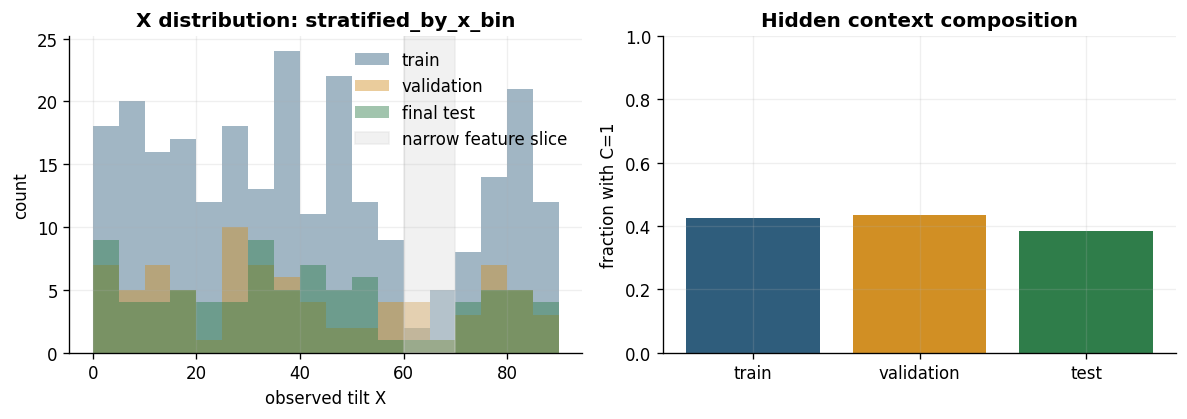

In [4]:
# Change these values, then rerun this cell.
split_to_inspect = split_type
alternative_splits = ["iid_random", "range_holdout", "context_shifted"]
local_region = (60, 70)
local_radius = 5.0

suites_to_compare = {split_to_inspect: make_split_suite(base_data, split_type=split_to_inspect, seed=dataset_seed)}
for name in alternative_splits:
    suites_to_compare[name] = make_split_suite(base_data, split_type=name, seed=dataset_seed)

role_rows = [
    ["training", "fits weights", "$\\theta_t \\leftarrow \\mathcal{O}(\\mathcal{D}_{\\mathrm{train}})$"],
    ["validation", "selects checkpoint or procedure", "$t^*=\\arg\\min_t \\widehat R_{\\mathrm{val}}(h_{\\theta_t})$"],
    ["final test", "assesses the fixed candidate once", "$\\widehat R_{\\mathrm{test}}(h_{\\theta^*})$"],
    ["diagnostic", "probes behaviour and failure modes", "slices, density, stress, shifted context"],
]
display_table(["Evidence source", "Role", "Mathematical use"], role_rows)

display_table(
    ["Split", "Set", "n", "min X", "max X", "mean Y", "frac C=1", f"n in {local_region}", "median local support"],
    [[name, *row] for name, suite in suites_to_compare.items() for row in describe_split(suite)],
)

plot_split_distributions(suites_to_compare[split_to_inspect])

### Plot interpretation

The histogram shows where each split has evidence along $X$. The bar chart shows the hidden-context mixture in each split. If those distributions differ, validation and final-test scores answer different questions.

### Mathematical unpacking

A split assigns non-overlapping roles:

$$
\mathcal{D}=\mathcal{D}_{\mathrm{train}}\cup\mathcal{D}_{\mathrm{val}}\cup\mathcal{D}_{\mathrm{test}},
\qquad
\mathcal{D}_{a}\cap\mathcal{D}_{b}=\varnothing.
$$

Training fits weights:

$$
\theta_t\leftarrow\mathcal{O}(\mathcal{D}_{\mathrm{train}}).
$$

Validation selects a checkpoint:

$$
t^*=\arg\min_t \widehat R_{\mathrm{val}}(h_{\theta_t}).
$$

The final test set assesses the already fixed candidate:

$$
\widehat R_{\mathrm{test}}(h_{\theta_{t^*}}).
$$

### Takeaway

If test results change the model, stopping rule, architecture, preprocessing, or reporting choice, then the test set has become validation evidence.

<br>

## 4. What Does Average Performance Show?

### Motivation

Aggregate metrics are the first pass. They answer whether the model performs well on average over an evidence set.

They do not say where the model is wrong.

This section asks:

$$
\text{What is the average predictive error on each evidence set?}
$$

### Minimal example

The cell compares simple baselines and the selected MLP on train, validation, and final test sets.

In [5]:
# Change these values, then rerun this cell.
baseline_degree = 7
ridge_lambda = 1e-3
metric_names = ["RMSE", "MAE", "Bias", "R2"]

baselines = [
    fit_mean_baseline(split_suite["train"]),
    fit_linear_baseline(split_suite["train"]),
    fit_polynomial_baseline(split_suite["train"], degree=baseline_degree, ridge_lambda=ridge_lambda),
]
models_to_compare = baselines + [reference_mlp]

rows = []
for model in models_to_compare:
    for split_key in ["train", "val", "test"]:
        data = split_suite[split_key]
        pred = predict_model(model, data)
        metrics = regression_metrics(data["y"], pred)
        rows.append([model["name"], data["name"], len(data["x"])] + [metrics[name] for name in metric_names])

display_table(["Model", "Evidence", "n", *metric_names], rows)

display_table(
    ["Dashboard quantity", "Value", "Evidence"],
    metric_dashboard(reference_mlp, split_suite, feature_region=feature_region),
)

| Model | Evidence | n | RMSE | MAE | Bias | R2 |
|---|---|---|---|---|---|---|
| Mean baseline | train | 254 | 0.4013 | 0.3299 | -1.399e-17 | 0 |
| Mean baseline | validation | 83 | 0.3752 | 0.3172 | 0.0131 | -0.001221 |
| Mean baseline | final test | 83 | 0.3737 | 0.317 | 0.004435 | -0.0001409 |
| Linear baseline | train | 254 | 0.4013 | 0.3301 | 1.259e-16 | 0.0001454 |
| Linear baseline | validation | 83 | 0.3754 | 0.3173 | 0.01321 | -0.00232 |
| Linear baseline | final test | 83 | 0.3739 | 0.3173 | 0.004485 | -0.001431 |
| Polynomial ridge degree 7 | train | 254 | 0.1871 | 0.125 | 3.121e-16 | 0.7825 |
| Polynomial ridge degree 7 | validation | 83 | 0.1599 | 0.1133 | -0.0093 | 0.8182 |
| Polynomial ridge degree 7 | final test | 83 | 0.1674 | 0.1211 | 0.01719 | 0.7992 |
| Reference MLP | train | 254 | 0.1808 | 0.1212 | 0.002302 | 0.7971 |
| Reference MLP | validation | 83 | 0.1661 | 0.1134 | -0.008585 | 0.8037 |
| Reference MLP | final test | 83 | 0.1536 | 0.1081 | 0.0114 | 0.8311 |

| Dashboard quantity | Value | Evidence |
|---|---|---|
| train RMSE | 0.1808 | train |
| validation RMSE | 0.1661 | validation |
| final test RMSE | 0.1536 | final test |
| (60, 70) RMSE | 0.1757 | final test slice |
| low-density RMSE | 0.1062 | lowest 30% support, cutoff 28.0 |
| shifted-context RMSE | 0.2315 | diagnostic set |
| worst-slice RMSE | 0.2127 | final test slices with n >= 10 |
| seed standard deviation |  | computed in the stability section |

### Table interpretation

The baselines set the scale of the task. A reference MLP should beat trivial baselines before its local behaviour is interpreted.

Low training error with much higher validation or final-test error suggests overfitting or mismatch. High training error suggests weak optimisation, insufficient capacity, or a weak signal.

### Mathematical unpacking

For squared-error evaluation:

$$
\widehat{\mathrm{RMSE}}(s)=
\sqrt{\frac{1}{n}\sum_{i=1}^{n}(s(x_i)-y_i)^2}.
$$

For absolute-error evaluation:

$$
\widehat{\mathrm{MAE}}(s)=
\frac{1}{n}\sum_{i=1}^{n}|s(x_i)-y_i|.
$$

The signed residual mean estimates bias:

$$
\widehat{\mathrm{Bias}}(s)=
\frac{1}{n}\sum_{i=1}^{n}(s(x_i)-y_i).
$$

### Takeaway

Aggregate metrics are necessary but not sufficient. They establish a baseline, then the rest of the notebook asks what the average hides.

<br>

## 5. What Function Did the MLP Learn?

### Motivation

A table of metrics does not show the function the MLP learned. In this one-dimensional setting, we can plot the selected function and inspect where it follows the data, smooths over a feature, or behaves oddly.

This section asks:

$$
\text{What behaviour has the MLP actually learned as a function of }X\text{?}
$$

### Minimal example

The cell plots the selected MLP over an input grid, overlays observed data, optionally overlays baselines, and then plots residuals on a chosen evidence set.

| Evidence | n | RMSE | MAE | Bias | R2 |
|---|---|---|---|---|---|
| final test | 83 | 0.1536 | 0.1081 | 0.0114 | 0.8311 |

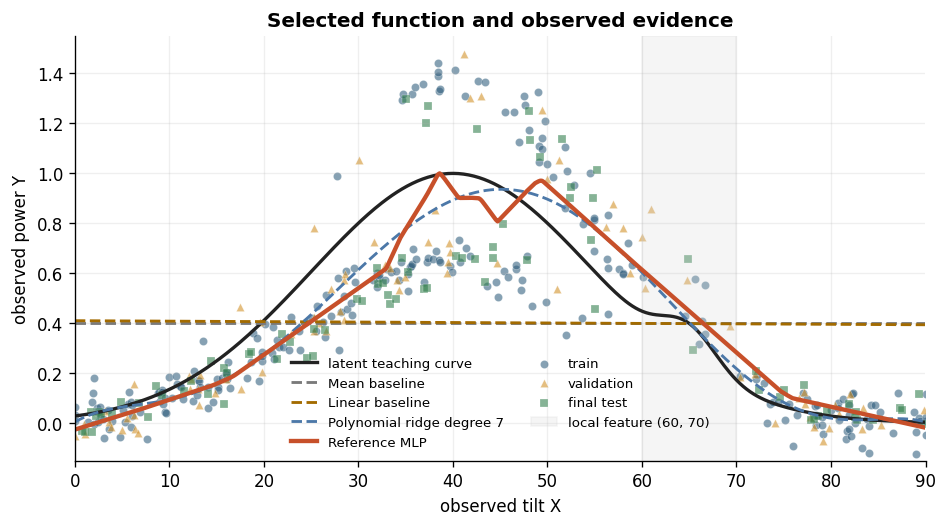

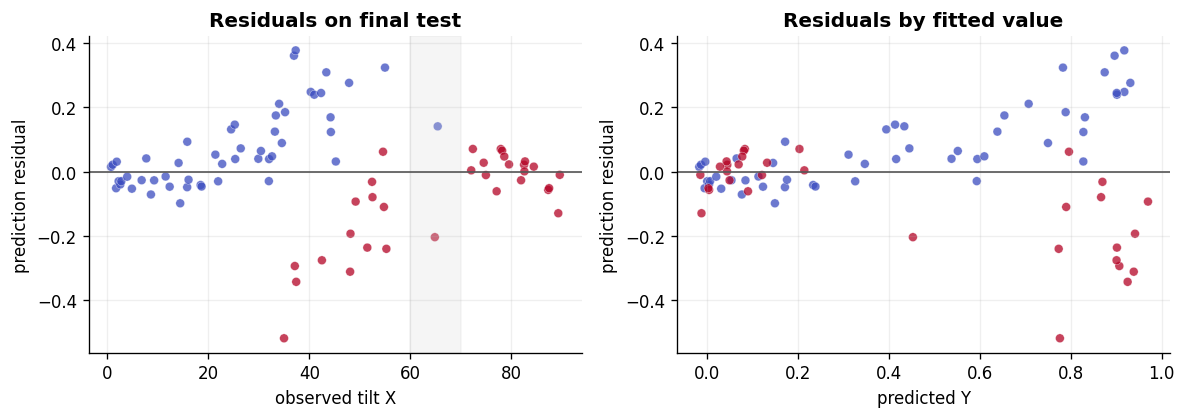

In [6]:
# Change these values, then rerun this cell.
show_train = True
show_val = True
show_test = True
show_baselines = True
highlight_region = (60, 70)
residual_evidence_set = "test"      # "train", "validation", "test", "shifted_context", "range_stress"

fig, ax = plt.subplots(figsize=(8, 4.5))
grid_data = make_grid_data()
ax.plot(GRID, f0(GRID), color=EVAL_COLORS["truth"], lw=2, label="latent teaching curve")

if show_baselines:
    for baseline, color in zip(baselines, ["#7A7A7A", "#A36B00", "#4C78A8"]):
        ax.plot(GRID, predict_model(baseline, grid_data), lw=1.7, ls="--", color=color, label=baseline["name"])

ax.plot(GRID, predict_model(reference_mlp, grid_data), color=EVAL_COLORS["fit"], lw=2.6, label=reference_mlp["name"])

for key, marker, show in [("train", "o", show_train), ("val", "^", show_val), ("test", "s", show_test)]:
    if show:
        data = split_suite[key]
        ax.scatter(
            data["x"],
            data["y"],
            s=24,
            alpha=0.58,
            marker=marker,
            color=EVAL_COLORS[key],
            edgecolor="white",
            linewidth=0.25,
            label=data["name"],
        )

ax.axvspan(highlight_region[0], highlight_region[1], color=EVAL_COLORS["support"], alpha=0.25, label=f"local feature {highlight_region}")
ax.set_xlim(0, 90)
ax.set_ylim(-0.15, 1.55)
ax.set_xlabel("observed tilt X")
ax.set_ylabel("observed power Y")
ax.set_title("Selected function and observed evidence")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()

residual_data = get_evidence_set(split_suite, residual_evidence_set)
plot_residuals(reference_mlp, residual_data, title=f"Residuals on {residual_data['name']}")

residual_pred = predict_model(reference_mlp, residual_data)
residual_metrics = regression_metrics(residual_data["y"], residual_pred)
display_table(
    ["Evidence", "n", "RMSE", "MAE", "Bias", "R2"],
    [[residual_data["name"], len(residual_data["x"]), residual_metrics["RMSE"], residual_metrics["MAE"], residual_metrics["Bias"], residual_metrics["R2"]]],
)

### Plot interpretation

The curve is the realised function $x\mapsto s(x)$. The residual plot shows whether errors are random, local, or systematic. A strong average score can still hide a missed feature or a biased region.

### Mathematical unpacking

The plotted object is:

$$
x\mapsto s(x).
$$

For each evaluated point, the residual is:

$$
r_i=s(x_i)-y_i.
$$

A region-specific residual bias is:

$$
\widehat b_A=
\frac{1}{|A|}\sum_{i:x_i\in A}r_i.
$$

### Takeaway

Visual inspection is not a replacement for metrics. It shows function behaviour and error structure that aggregate metrics can hide.

<br>

## 6. Where Does Performance Change?

### Motivation

A model can perform well overall while failing for a subgroup, range, context, or scientifically important region.

This section asks:

$$
\text{Where does performance vary?}
$$

### Minimal example

The cell computes metrics by editable slices of $X$, local density, the local feature region, or hidden context.

| Slice | Count | RMSE | MAE | Bias | Notes | Evidence warning |
|---|---|---|---|---|---|---|
| 0 <= X < 15 | 17 | 0.04336 | 0.03779 | -0.02187 |  |  |
| 15 <= X < 30 | 13 | 0.07182 | 0.06094 | 0.03135 |  |  |
| 30 <= X < 45 | 21 | 0.2475 | 0.2131 | 0.07372 |  |  |
| 45 <= X < 60 | 12 | 0.1966 | 0.1661 | -0.05035 |  |  |
| 60 <= X < 70 | 2 | 0.1757 | 0.1728 | -0.03161 | narrow feature | low count |
| 70 <= X <= 90 | 18 | 0.05105 | 0.04027 | 0.001643 |  |  |

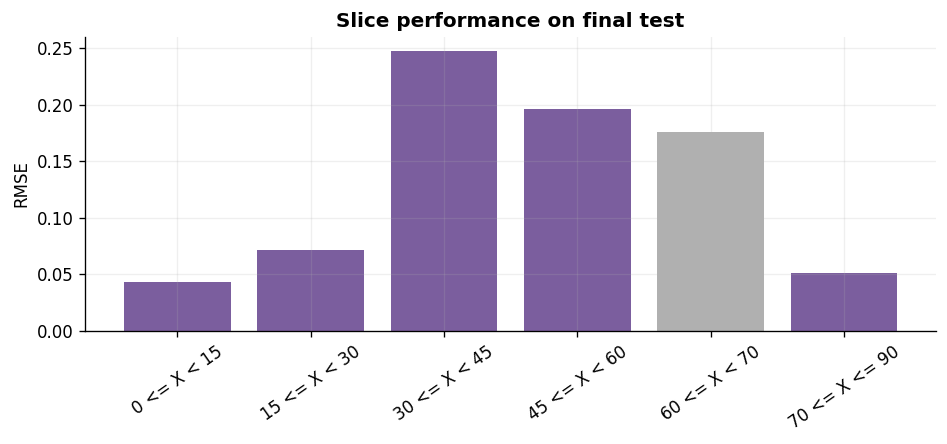

In [7]:
# Change these values, then rerun this cell.
slice_mode = "x_bins"            # "x_bins", "density", "feature", "context"
slice_evidence_set = "test"      # "train", "validation", "test", "shifted_context", "range_stress"
x_bins = [0, 15, 30, 45, 60, 70, 90]
local_radius = 5.0
min_slice_count = 12

slice_data = get_evidence_set(split_suite, slice_evidence_set)
slice_pred = predict_model(reference_mlp, slice_data)

if slice_mode == "x_bins":
    slices = {}
    for left, right in zip(x_bins[:-1], x_bins[1:]):
        if right == x_bins[-1]:
            mask = (slice_data["x"] >= left) & (slice_data["x"] <= right)
            label = f"{left} <= X <= {right}"
        else:
            mask = (slice_data["x"] >= left) & (slice_data["x"] < right)
            label = f"{left} <= X < {right}"
        slices[label] = mask
elif slice_mode == "density":
    _, low, high, low_rule, high_rule = density_masks(slice_data, split_suite["train"], radius=local_radius)
    slices = {low_rule: low, high_rule: high}
elif slice_mode == "feature":
    local = feature_mask(slice_data, feature_region)
    slices = {f"X in {feature_region}": local, f"X outside {feature_region}": ~local}
elif slice_mode == "context":
    slices = {"C = 0": slice_data["c"] == 0, "C = 1": slice_data["c"] == 1}
else:
    raise ValueError(f"unknown slice_mode: {slice_mode}")

raw_rows = slice_metrics(slice_data, slice_pred, slices)
slice_rows = []
for row in raw_rows:
    warning = "low count" if row[1] < min_slice_count else ""
    slice_rows.append([*row, warning])

display_table(["Slice", "Count", "RMSE", "MAE", "Bias", "Notes", "Evidence warning"], slice_rows)

fig, ax = plt.subplots(figsize=(8, 3.8))
labels = [row[0] for row in raw_rows]
rmse = [row[2] for row in raw_rows]
counts = [row[1] for row in raw_rows]
colors = [EVAL_COLORS["diagnostic"] if count >= min_slice_count else "#B0B0B0" for count in counts]
ax.bar(labels, rmse, color=colors)
ax.set_ylabel("RMSE")
ax.set_title(f"Slice performance on {slice_data['name']}")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()

### Plot interpretation

The bar chart compares error across behavioural regions. Grey bars mark slices with weak evidence because their counts are below the chosen threshold.

### Mathematical unpacking

For a slice $A$:

$$
\widehat R_A(s)=
\frac{1}{|A|}\sum_{i:x_i\in A}\ell(s(x_i),y_i).
$$

Slice metrics are incomplete without the count:

$$
n_A=|\{i:x_i\in A\}|.
$$

### Takeaway

A slice metric without a slice count is incomplete. Local performance claims require local evidence.

<br>

## 7. What Happens in Interpolation, Sparse Support, and Holdout Regimes?

### Motivation

The MLP predicts everywhere in the plotted range, but the dataset does not provide equal evidence everywhere. Dense interpolation and sparse support are different evidence regimes.

This section asks:

$$
\text{Does the model fail where the data provide weak support?}
$$

### Minimal example

The cell uses local training density to label evaluated points as high-support or low-support. It also compares those results with a range-stress diagnostic set.

| Regime | Count | RMSE | MAE | Bias |
|---|---|---|---|---|
| all evaluated points | 83 | 0.1536 | 0.1081 | 0.0114 |
| dense interpolation: N_r(x) >= 20 | 77 | 0.156 | 0.1093 | 0.01395 |
| sparse support: lowest 30% support, cutoff 28.0 | 26 | 0.1062 | 0.07395 | -0.008845 |
| range-stress diagnostic | 240 | 0.1871 | 0.1474 | 0.1083 |

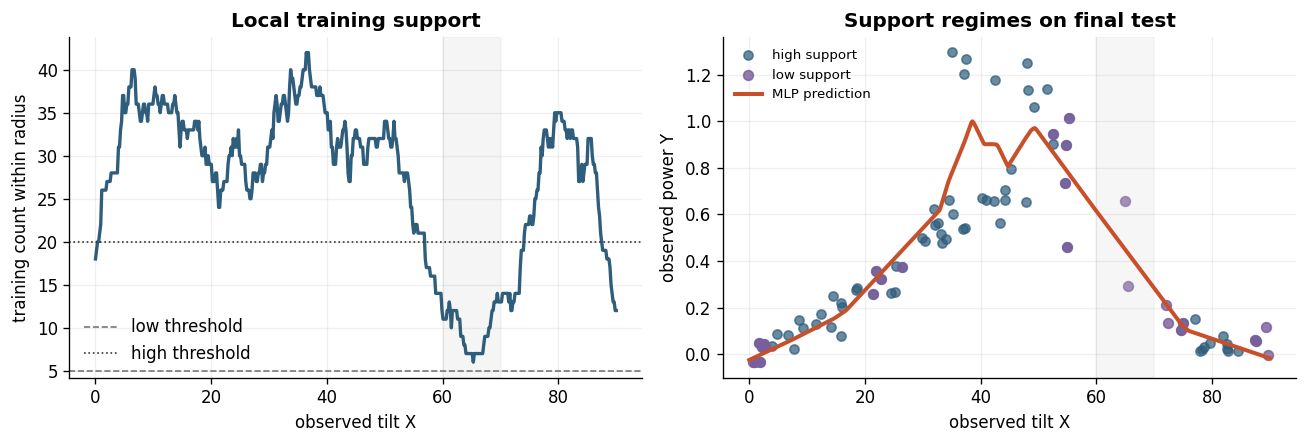

In [8]:
# Change these values, then rerun this cell.
density_evidence_set = "test"      # "validation", "test", "range_stress", "shifted_context"
density_radius = 5.0
low_density_threshold = 5
high_density_threshold = 20

support_data = get_evidence_set(split_suite, density_evidence_set)
support_pred = predict_model(reference_mlp, support_data)
counts, low, high, low_rule, high_rule = density_masks(
    support_data,
    split_suite["train"],
    radius=density_radius,
    low_threshold=low_density_threshold,
    high_threshold=high_density_threshold,
)

support_rows = []
for label, mask in [
    ["all evaluated points", np.ones(len(support_data["x"]), dtype=bool)],
    [f"dense interpolation: {high_rule}", high],
    [f"sparse support: {low_rule}", low],
]:
    metrics = safe_region_metrics(support_data, support_pred, mask)
    support_rows.append([label, metrics["n"], metrics["RMSE"], metrics["MAE"], metrics["Bias"]])

range_data = split_suite["diagnostics"]["range_stress"]
range_pred = predict_model(reference_mlp, range_data)
range_metrics = regression_metrics(range_data["y"], range_pred)
support_rows.append(["range-stress diagnostic", len(range_data["x"]), range_metrics["RMSE"], range_metrics["MAE"], range_metrics["Bias"]])

display_table(["Regime", "Count", "RMSE", "MAE", "Bias"], support_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
counts_grid = local_count(GRID, split_suite["train"]["x"], radius=density_radius)
axes[0].plot(GRID, counts_grid, color=EVAL_COLORS["train"], lw=2)
axes[0].axhline(low_density_threshold, color="#777777", ls="--", lw=1, label="low threshold")
axes[0].axhline(high_density_threshold, color="#333333", ls=":", lw=1, label="high threshold")
axes[0].axvspan(feature_region[0], feature_region[1], color=EVAL_COLORS["support"], alpha=0.25)
axes[0].set_xlabel("observed tilt X")
axes[0].set_ylabel("training count within radius")
axes[0].set_title("Local training support")
axes[0].legend()

axes[1].scatter(support_data["x"][high], support_data["y"][high], s=30, alpha=0.72, color=EVAL_COLORS["train"], label="high support")
axes[1].scatter(support_data["x"][low], support_data["y"][low], s=34, alpha=0.82, color=EVAL_COLORS["diagnostic"], label="low support")
axes[1].plot(GRID, predict_model(reference_mlp, make_grid_data()), color=EVAL_COLORS["fit"], lw=2.4, label="MLP prediction")
axes[1].axvspan(feature_region[0], feature_region[1], color=EVAL_COLORS["support"], alpha=0.22)
axes[1].set_xlabel("observed tilt X")
axes[1].set_ylabel("observed power Y")
axes[1].set_title(f"Support regimes on {support_data['name']}")
axes[1].legend(fontsize=8)
plt.tight_layout()

### Plot interpretation

The local-support plot shows where the training set gives nearby evidence. Predictions in low-support regions are more dependent on the MLP's inductive bias than on local observations.

### Mathematical unpacking

Use the training set to define local support:

$$
N_r(x)=
\sum_{i\in\mathcal{D}_{\mathrm{train}}}
\mathbf{1}\{|x_i-x|\leq r\}.
$$

Then compare high-support and low-support risks:

$$
\widehat R_{\mathrm{high}}(s)
\qquad\text{and}\qquad
\widehat R_{\mathrm{low}}(s).
$$

### Takeaway

Dense interpolation is evidence-backed behaviour. Sparse-support and range-stress behaviour may be driven mostly by assumptions from $\mathcal{H}_{\mathrm{MLP}}$ and $\mathcal{O}$.

<br>

## 8. Does Behaviour Survive Context Shift?

### Motivation

If hidden context changes the relationship between $X$ and $Y$, an MLP trained only on $X$ may work under the observed mixture but fail when the mixture changes.

This section asks:

$$
\text{Does the learned relationship transfer when the context mixture changes?}
$$

### Minimal example

The cell evaluates the fixed $X$-only MLP on a shifted-context diagnostic set. It optionally trains a context-aware MLP for comparison.

| Model | Evidence | n | frac C=1 | RMSE | Bias C=0 | Bias C=1 |
|---|---|---|---|---|---|---|
| X-only MLP | validation | 83 | 0.4337 | 0.1661 | 0.05408 | -0.0904 |
| X-only MLP | final test | 83 | 0.3855 | 0.1536 | 0.07435 | -0.08894 |
| X-only MLP | shifted_context | 240 | 0.09167 | 0.2315 | 0.2124 | -0.02586 |
| Context-aware MLP | validation | 83 | 0.4337 | 0.07666 | 0.0005909 | -0.01499 |
| Context-aware MLP | final test | 83 | 0.3855 | 0.07647 | 0.0112 | -0.0006694 |
| Context-aware MLP | shifted_context | 240 | 0.09167 | 0.07882 | -0.02097 | -0.004331 |

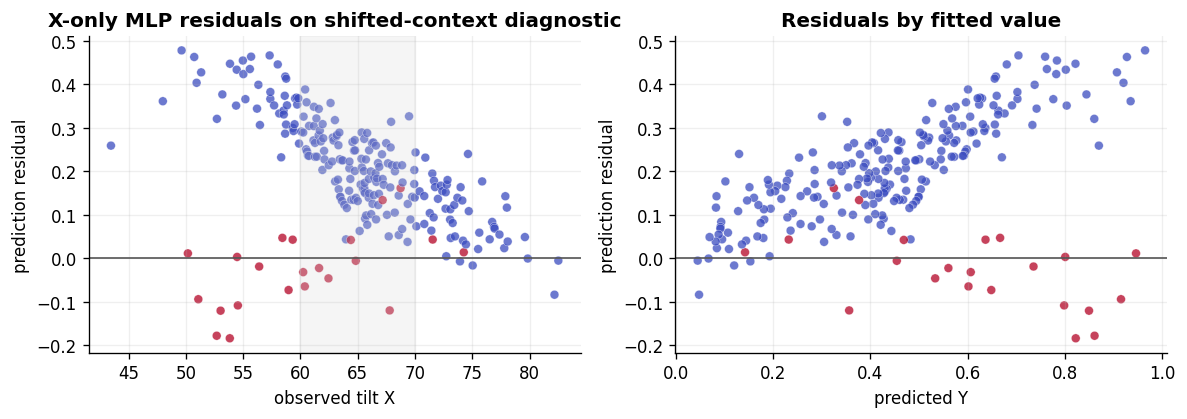

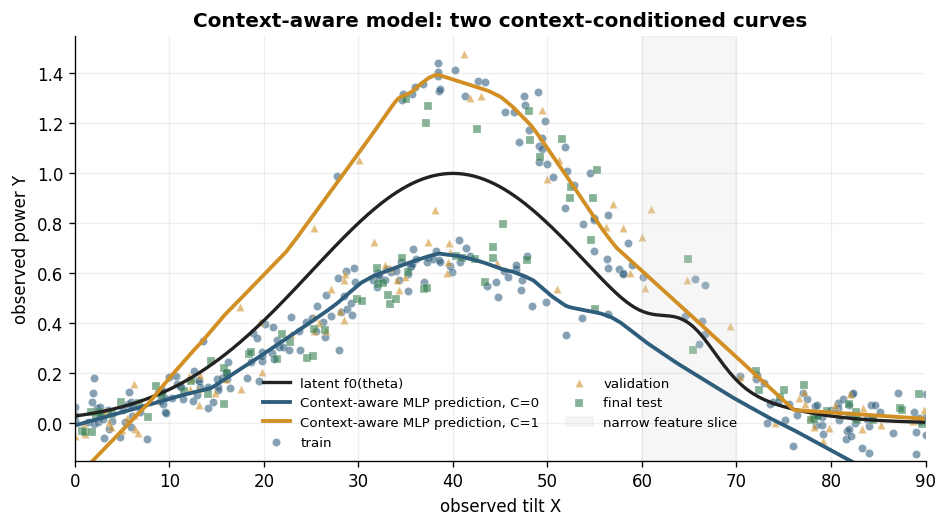

In [9]:
# Change these values, then rerun this cell.
evaluate_context_model = True
context_input_keys = ("x", "c")
shift_set_name = "shifted_context"       # "shifted_context", "balanced_context", "range_stress"
context_epochs = 140

shift_data = split_suite["diagnostics"][shift_set_name]
models_for_shift = [("X-only MLP", reference_mlp)]

if evaluate_context_model:
    context_config = compact_train_config(
        reference_config,
        name="Context-aware MLP",
        input_keys=context_input_keys,
        epochs=context_epochs,
        seed=model_seed + 91,
    )
    context_mlp = train_model(split_suite["train"], split_suite["val"], context_config)
    models_for_shift.append(("Context-aware MLP", context_mlp))
else:
    context_mlp = None

shift_rows = []
for label, model in models_for_shift:
    for evidence_name, data in [("validation", split_suite["val"]), ("final test", split_suite["test"]), (shift_set_name, shift_data)]:
        pred = predict_model(model, data)
        metrics = regression_metrics(data["y"], pred)
        bias_c0 = safe_region_metrics(data, pred, data["c"] == 0)["Bias"]
        bias_c1 = safe_region_metrics(data, pred, data["c"] == 1)["Bias"]
        shift_rows.append([label, evidence_name, len(data["x"]), np.mean(data["c"]), metrics["RMSE"], bias_c0, bias_c1])

display_table(["Model", "Evidence", "n", "frac C=1", "RMSE", "Bias C=0", "Bias C=1"], shift_rows)

plot_residuals(reference_mlp, shift_data, title=f"X-only MLP residuals on {shift_data['name']}")
if evaluate_context_model:
    plot_predictions(context_mlp, split_suite, title="Context-aware model: two context-conditioned curves", show_context=True)

### Plot interpretation

The residual plot tests whether errors become structured under a changed context mixture. The context-aware plot shows what changes when $C$ becomes an observed input, which also changes the effective hypothesis space.

### Mathematical unpacking

The observed relationship may depend on the context mixture:

$$
\mathbb{E}[Y\mid X=x]
=
\sum_c
\mathbb{E}[Y\mid X=x,C=c]P(C=c\mid X=x).
$$

A context shift means:

$$
P_{\mathrm{shift}}(C\mid X)\neq P_{\mathrm{train}}(C\mid X).
$$

### Takeaway

Good random-test performance does not prove robustness. Robustness requires evidence under the shifted condition or a justified argument that the shift is irrelevant.

<br>

## 9. What Claim Does the Evidence Support?

### Motivation

The final output should not be one score. It should be a claim-specific report that names supported, unsupported, and unresolved behaviours.

This section asks:

$$
\text{What can we now say responsibly about the selected MLP?}
$$

### Minimal example

The cell repeats training over several seeds, then combines aggregate, local, sparse-support, shifted-context, and stability diagnostics into a compact report.

| Seed | Selected epoch | Final-test RMSE | (60, 70) RMSE |
|---|---|---|---|
| 11 | 23 | 0.1687 | 0.1773 |
| 17 | 80 | 0.1594 | 0.1738 |
| 23 | 90 | 0.1639 | 0.1742 |
| 31 | 117 | 0.1625 | 0.1786 |
| 43 | 16 | 0.1723 | 0.1762 |

| Claim | Decision | Evidence | Limitation |
|---|---|---|---|
| IID prediction | unsupported | final-test RMSE = 0.154 | depends on the observed split distribution |
| Dense interpolation | unsupported | N_r(x) >= 20; RMSE = 0.156; n = 77 | only where training support is strong |
| Local feature | unresolved | (60, 70) RMSE = 0.176; n = 2 | low count weakens evidence even when error is small |
| Sparse support | supported | lowest 30% support, cutoff 28.0; RMSE = 0.106; n = 26 | may be assumption-driven rather than evidence-backed |
| Context shift | unsupported | shifted RMSE = 0.232; penalty = 1.51x | depends on the deployment context mixture |
| Stability | supported | test std = 0.005; local std = 0.002 | one selected run may not represent all seeds |

| Observation | Likely issue | What to check next |
|---|---|---|
| High training and validation error | $\mathcal{H}_{\mathrm{MLP}}$ or $\mathcal{O}$ | capacity, optimiser, learning rate |
| Low training error, high validation error | overfitting or split mismatch | regularisation and validation design |
| Good aggregate error, bad slice error | claim-specific local failure | slice count and targeted data |
| Good dense error, bad sparse error | $\mathcal{D}$ support weakness | local density and range stress |
| Good IID test, bad shifted diagnostic | distribution shift | context and deployment distribution |
| Large seed variation | $\mathcal{O}$ instability | seed sweep, stopping rule, learning rate |

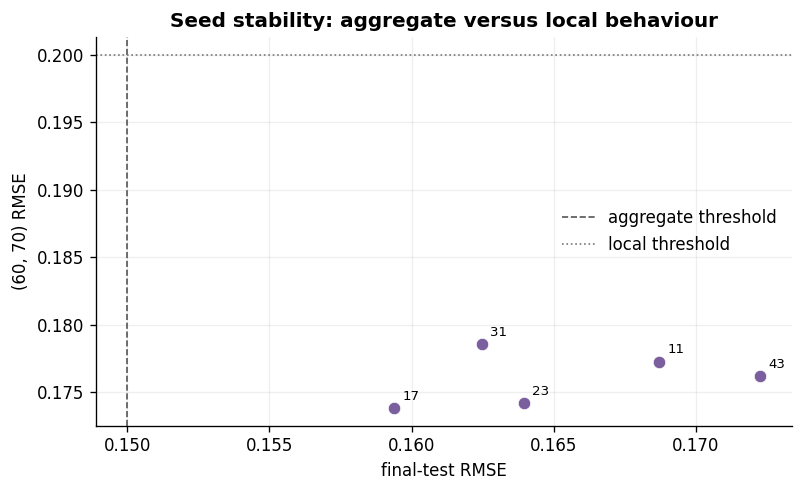

In [10]:
# Change these values, then rerun this cell.
seed_values = [11, 17, 23, 31, 43]
stability_epochs = 120
rmse_threshold = 0.15
feature_rmse_threshold = 0.20
min_feature_count = 20
shift_penalty_threshold = 1.5
seed_std_threshold = 0.04

stability_models, stability_rows = run_seed_sweep(split_suite, reference_config, seeds=seed_values, epochs=stability_epochs)
seed_test_rmse = np.array([row[2] for row in stability_rows], dtype=float)
seed_feature_rmse = np.array([row[3] for row in stability_rows], dtype=float)
seed_std = float(np.nanstd(seed_test_rmse))
feature_seed_std = float(np.nanstd(seed_feature_rmse))

display_table(["Seed", "Selected epoch", "Final-test RMSE", f"{feature_region} RMSE"], stability_rows)

test_data = split_suite["test"]
test_pred = predict_model(reference_mlp, test_data)
test_metrics = regression_metrics(test_data["y"], test_pred)
feature = feature_mask(test_data, feature_region)
feature_metrics = safe_region_metrics(test_data, test_pred, feature)
_, low, high, low_rule, high_rule = density_masks(test_data, split_suite["train"], radius=density_radius)
low_metrics = safe_region_metrics(test_data, test_pred, low)
high_metrics = safe_region_metrics(test_data, test_pred, high)
shift_data = split_suite["diagnostics"]["shifted_context"]
shift_pred = predict_model(reference_mlp, shift_data)
shift_metrics = regression_metrics(shift_data["y"], shift_pred)
shift_penalty = shift_metrics["RMSE"] / max(test_metrics["RMSE"], 1e-12)

def decide_metric(value, threshold, count=None, minimum=None):
    if not np.isfinite(value):
        return "unresolved"
    if count is not None and minimum is not None and count < minimum:
        return "unresolved"
    return "supported" if value <= threshold else "unsupported"

report_rows = [
    [
        "IID prediction",
        decide_metric(test_metrics["RMSE"], rmse_threshold),
        f"final-test RMSE = {test_metrics['RMSE']:.3f}",
        "depends on the observed split distribution",
    ],
    [
        "Dense interpolation",
        decide_metric(high_metrics["RMSE"], rmse_threshold, high_metrics["n"], min_feature_count),
        f"{high_rule}; RMSE = {high_metrics['RMSE']:.3f}; n = {high_metrics['n']}",
        "only where training support is strong",
    ],
    [
        "Local feature",
        decide_metric(feature_metrics["RMSE"], feature_rmse_threshold, feature_metrics["n"], min_feature_count),
        f"{feature_region} RMSE = {feature_metrics['RMSE']:.3f}; n = {feature_metrics['n']}",
        "low count weakens evidence even when error is small",
    ],
    [
        "Sparse support",
        "supported" if np.isfinite(low_metrics["RMSE"]) and low_metrics["RMSE"] <= rmse_threshold else "unsupported",
        f"{low_rule}; RMSE = {low_metrics['RMSE']:.3f}; n = {low_metrics['n']}",
        "may be assumption-driven rather than evidence-backed",
    ],
    [
        "Context shift",
        "supported" if shift_penalty <= shift_penalty_threshold else "unsupported",
        f"shifted RMSE = {shift_metrics['RMSE']:.3f}; penalty = {shift_penalty:.2f}x",
        "depends on the deployment context mixture",
    ],
    [
        "Stability",
        "supported" if seed_std <= seed_std_threshold and feature_seed_std <= 2 * seed_std_threshold else "unsupported",
        f"test std = {seed_std:.3f}; local std = {feature_seed_std:.3f}",
        "one selected run may not represent all seeds",
    ],
]

display_table(["Claim", "Decision", "Evidence", "Limitation"], report_rows)

failure_rows = [
    ["High training and validation error", "$\\mathcal{H}_{\\mathrm{MLP}}$ or $\\mathcal{O}$", "capacity, optimiser, learning rate"],
    ["Low training error, high validation error", "overfitting or split mismatch", "regularisation and validation design"],
    ["Good aggregate error, bad slice error", "claim-specific local failure", "slice count and targeted data"],
    ["Good dense error, bad sparse error", "$\\mathcal{D}$ support weakness", "local density and range stress"],
    ["Good IID test, bad shifted diagnostic", "distribution shift", "context and deployment distribution"],
    ["Large seed variation", "$\\mathcal{O}$ instability", "seed sweep, stopping rule, learning rate"],
]
display_table(["Observation", "Likely issue", "What to check next"], failure_rows)

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.scatter(seed_test_rmse, seed_feature_rmse, s=55, color=EVAL_COLORS["diagnostic"], edgecolor="white", linewidth=0.4)
for seed, x_value, y_value in zip(seed_values, seed_test_rmse, seed_feature_rmse):
    ax.annotate(str(seed), (x_value, y_value), textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.axvline(rmse_threshold, color="#555555", ls="--", lw=1, label="aggregate threshold")
ax.axhline(feature_rmse_threshold, color="#777777", ls=":", lw=1, label="local threshold")
ax.set_xlabel("final-test RMSE")
ax.set_ylabel(f"{feature_region} RMSE")
ax.set_title("Seed stability: aggregate versus local behaviour")
ax.legend()
plt.tight_layout()

### Plot interpretation

The seed plot shows whether aggregate performance and local-feature performance move together. A tight cluster supports a more stable claim. A wide spread means one run is weak evidence.

### Mathematical unpacking

Each repeated run gives a selected model:

$$
s^{(r)}=h_{\theta_{t^*}^{(r)}}.
$$

The stability question is about the distribution of reported risks:

$$
\{\widehat R_{\mathrm{claim}}(s^{(r)})\}_{r=1}^{R}.
$$

The final report applies the protocol:

$$
\Pi(s,\mathcal{D},\mathrm{claim})
\rightarrow
\{\text{supported},\text{unsupported},\text{unresolved}\}.
$$

### Takeaway

A trained MLP is not evaluated by asking only:

$$
\text{Is the score good?}
$$

A stronger evaluation asks:

$$
\text{Where is it good, where does it fail, and what claim does the evidence support?}
$$